In [113]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import joblib 


# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [114]:
run="1"

In [115]:
bdt_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/BDT_2021_results_limited_sideband_b.pk")
ANN_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/ANN_results_2021_relu_run"+run+"_limited_sideband_b.pk")

ANN_results['BDT']=bdt_results['Yhat']

ANN_results.head()

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,ele_Px,ele_Py,ele_Pz,pos_Px,pos_Py,pos_Pz,PhiKK,type,InvM,Class_pre,Class_adv,BDT
0,0.00000,1.947389,-9999.00000,-9999.000000,-9999.000000,128.574265,-26.242468,1448.840088,0.000778,0.037823,0.681471,0.109193,-0.048345,3.052011,0.0,tritrig,1.242431,0.078193,0.052717,0.274893
1,0.00000,0.712648,-9999.00000,-9999.000000,-9999.000000,310.184753,28.638279,1450.260986,0.018378,-0.019412,0.696336,0.038792,0.015841,0.982765,0.0,tritrig,0.998880,0.035404,0.055117,0.366471
2,0.00000,1.337766,-9999.00000,-9999.000000,-9999.000000,257.256561,-33.352058,1449.831665,-0.007168,0.050613,0.870454,0.052819,-0.026166,1.244959,0.0,tritrig,1.004985,0.007095,0.007150,0.431159
3,0.23627,0.536645,-205.57312,80.672951,1450.697144,302.939911,-65.740227,1450.590088,-0.022666,0.066558,1.247176,0.173245,-0.072815,1.608461,1.0,phiKK,1.020213,0.990532,0.991912,0.653133
4,0.00000,1.066258,-9999.00000,-9999.000000,-9999.000000,268.425415,-70.881042,1450.270996,0.011244,0.023878,0.522705,0.016216,-0.046444,0.989538,0.0,tritrig,1.023540,0.012705,0.008685,0.368537


# Compare Classifiers on testing data

In [116]:
# Split into tritrig and phiKK dataframes
test_df_tritrig = ANN_results[ANN_results['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = ANN_results[ANN_results['type']=="phiKK"].reset_index(drop=True)
test_df_wab = ANN_results[ANN_results['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])



Test AUROC: 0.9971


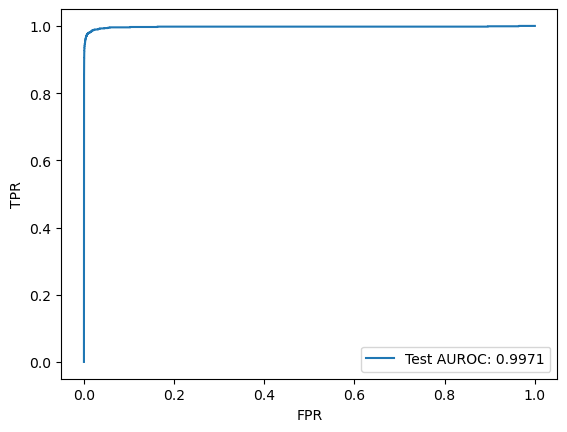

In [117]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.BDT, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

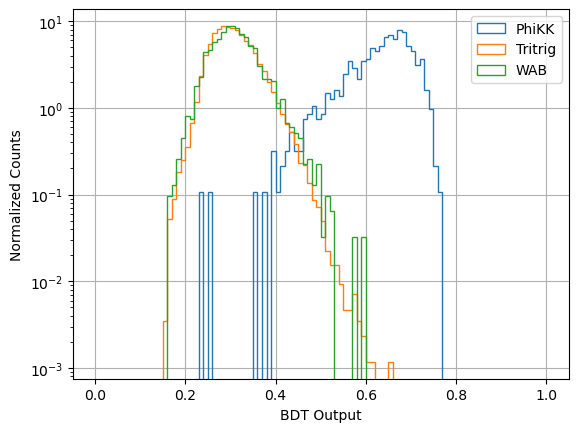

In [118]:
test_df_phiKK.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
#plt.axvline(x=0.4, color='k', linestyle='--', label ="selection line")
plt.xlabel('BDT Output')
plt.ylabel('Normalized Counts')
plt.yscale('log')
plt.legend()

Test AUROC: 0.9927


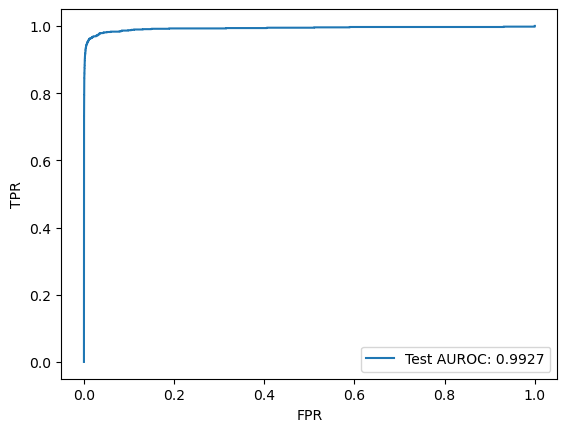

In [119]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_pre, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


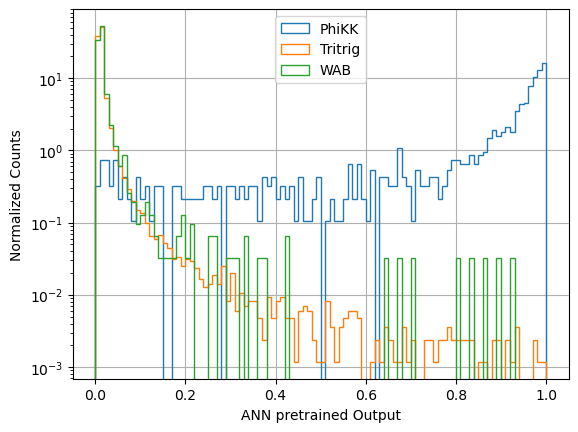

In [120]:
test_df_phiKK.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN pretrained Output')
plt.ylabel('Normalized Counts')
plt.legend()

Test AUROC: 0.9853


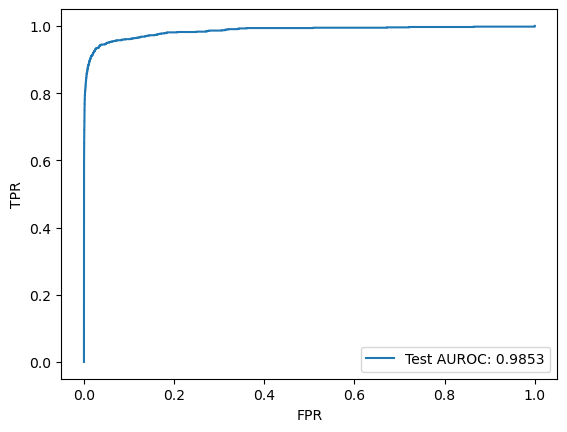

In [121]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_adv, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


In [122]:
a =tpr/fpr

masked = np.ma.masked_invalid(a) # masks inf and nan
if masked.count() == 0: raise ValueError("No finite values")
idx = masked.argmax()

thresholds[idx]

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_49729/3384453741.py:1: RuntimeWarning: divide by zero encountered in divide
  a =tpr/fpr
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_49729/3384453741.py:1: RuntimeWarning: invalid value encountered in divide
  a =tpr/fpr


np.float64(0.9878337498676696)

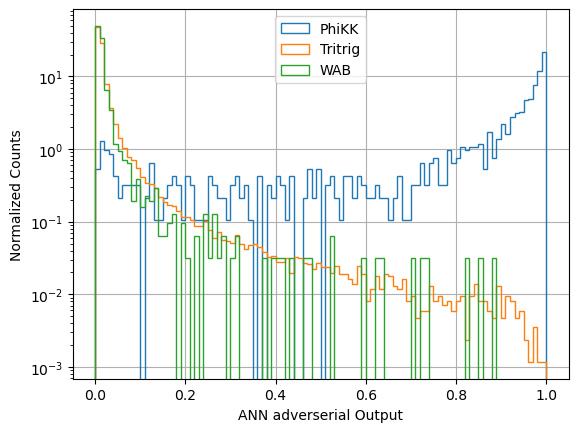

In [123]:
test_df_phiKK.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN adverserial Output')
plt.ylabel('Normalized Counts')
plt.legend()

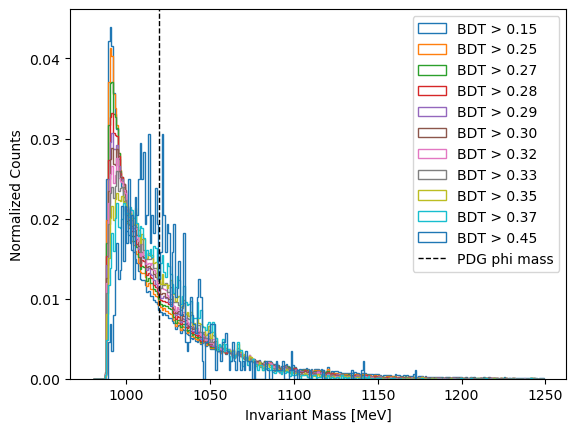

In [124]:
for sel in np.percentile(test_df_bkg['BDT'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['BDT']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'BDT > {sel:.2f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

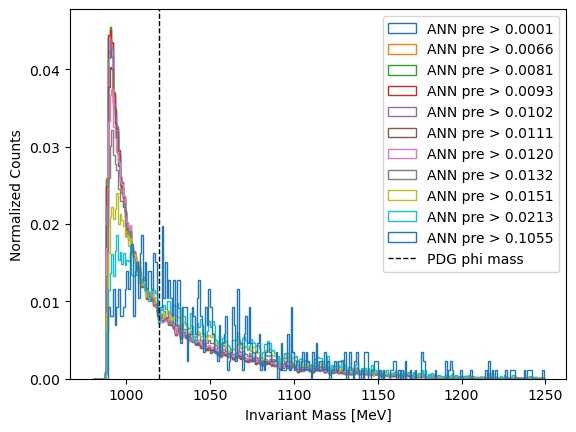

In [125]:
for sel in  np.percentile(test_df_bkg['Class_pre'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_pre']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN pre > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

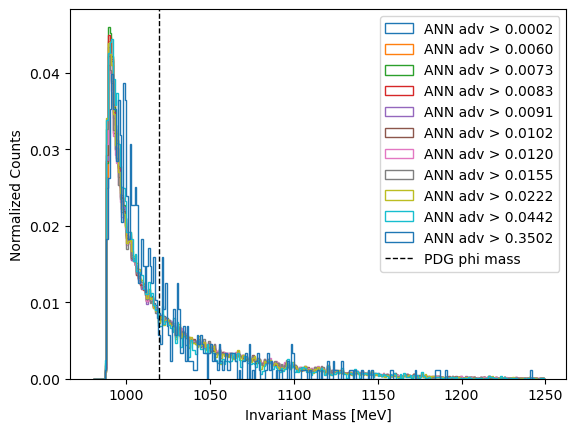

In [126]:
for sel in np.percentile(test_df_bkg['Class_adv'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_adv']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN adv > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

# Compare classifiers on weighted testing data

In [127]:
# Compine dfs according to expected proportions
df_test_combined = pd.concat([test_df_tritrig[0:13080], test_df_wab[0:3119], test_df_phiKK[0:1]], ignore_index=True, sort=False)

print(len(df_test_combined))

16200


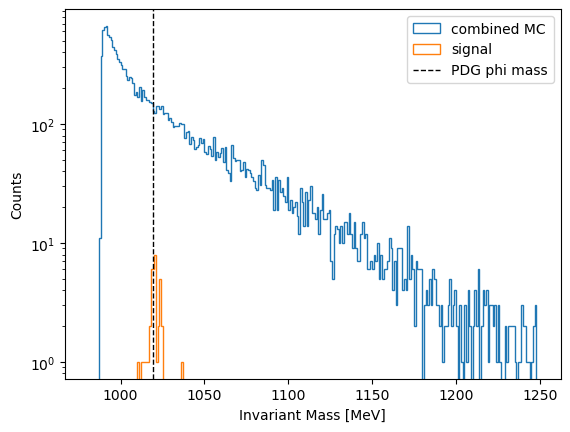

In [128]:
x_vals = 1000*df_test_combined.InvM
x_vals_sig = 1000*test_df_phiKK[0:39].InvM
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label="combined MC")
plt.hist(x_vals_sig, bins=np.arange(980,1250,1), histtype='step',label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

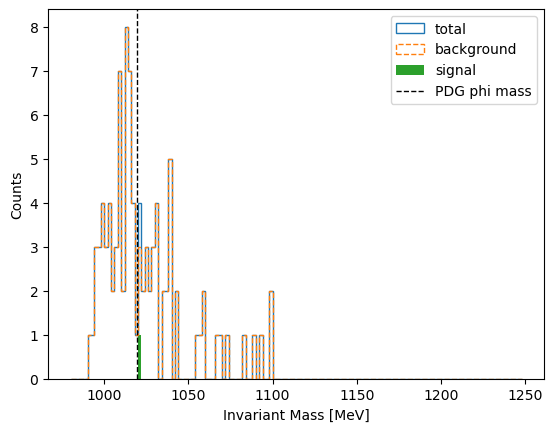

In [129]:
BDT_selection = np.percentile(test_df_bkg['BDT'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['BDT']>BDT_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

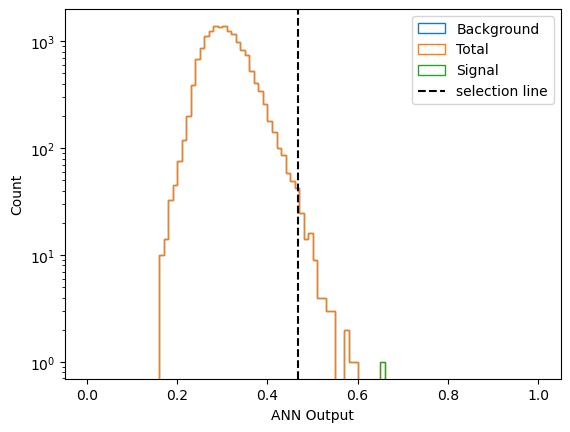

In [130]:
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['BDT'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.axvline(x=BDT_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

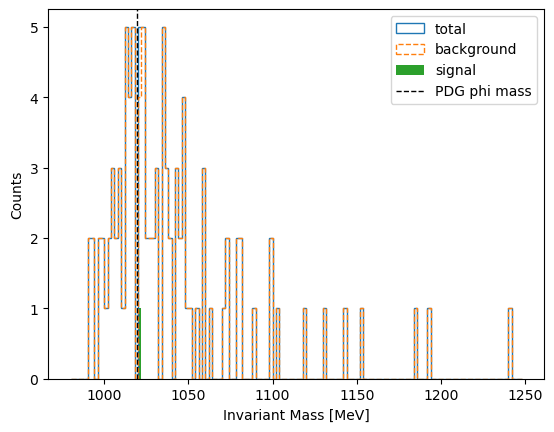

In [131]:
MLP_selection = np.percentile(test_df_bkg['Class_pre'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['Class_pre']>MLP_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

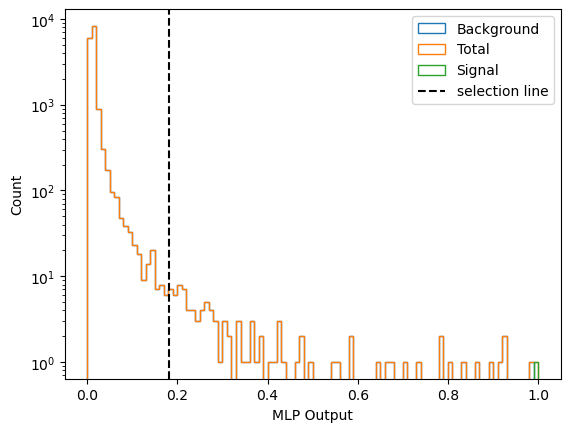

In [132]:
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_pre'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')

plt.axvline(x=MLP_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('MLP Output')
plt.ylabel('Count')

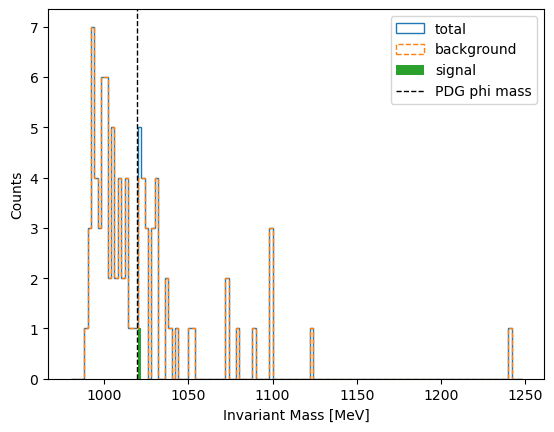

In [133]:
ANN_selection = np.percentile(test_df_bkg['Class_adv'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['Class_adv']>ANN_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

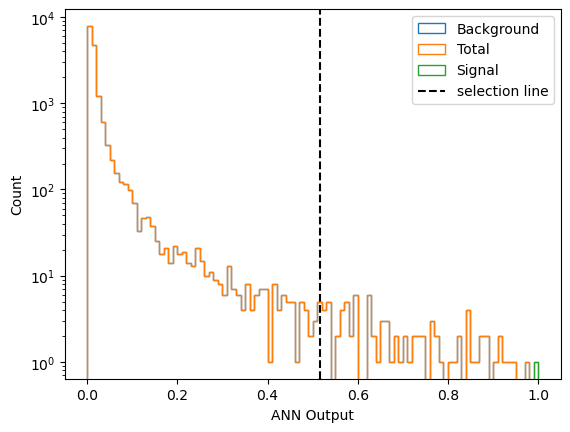

In [134]:
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_adv'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.axvline(x=ANN_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

# Apply ANN to data

In [135]:

X_final = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2021_data_limited.pk')

print(len(X_final))


57821


In [136]:
final_classifier = mytools.Classifier(in_features=X_final.shape[1]).to(device)
final_classifier.load_state_dict(torch.load("/Users/mghrear/data/ML_data/patch/classifier_adv_relu_run"+str(run)+"_limited_sideband_b.pt", map_location=device))
final_classifier.eval() 

Classifier(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=264, bias=False)
    (1): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=264, out_features=264, bias=False)
    (4): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=264, out_features=128, bias=False)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=128, bias=False)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=64, bias=False)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [137]:
final_dataset = TensorDataset(torch.from_numpy(X_final.to_numpy().astype(np.float32)) )
final_loader = DataLoader(final_dataset, batch_size=124, shuffle=False)

In [138]:
final_pred = mytools.test_final(final_loader, final_classifier, device)
final_pred=torch.sigmoid(torch.tensor(final_pred)).numpy()



Text(0, 0.5, 'Count')

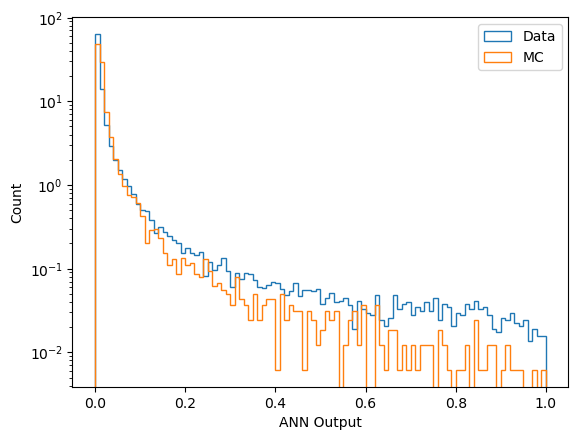

In [140]:
plt.hist(final_pred,bins=np.arange(0,1.01,0.01), histtype='step',density=True,label="Data")
plt.hist(df_test_combined['Class_adv'],bins=np.arange(0,1.01,0.01), histtype='step',density=True,label='MC')

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

In [141]:
X_final['pred'] = final_pred
X_final['InvM'] = mytools.get_InvM(X_final)

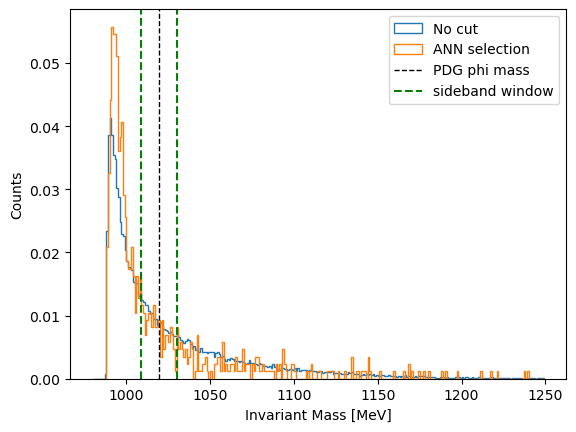

In [142]:
X_final_cut = X_final[X_final['pred']>ANN_selection].reset_index(drop=True)
x_vals = 1000*X_final_cut.InvM

X_final_cut = X_final[X_final['pred']>0].reset_index(drop=True)
x_vals2 = 1000*X_final_cut.InvM

plt.hist(x_vals2, bins=np.arange(980,1250,1), label="No cut", histtype='step',density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), label="ANN selection", histtype='step',density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.axvline(1030.3173980209851, color='g', linestyle='--', label='sideband window')
plt.axvline(1008.4829302730138, color='g', linestyle='--')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



# Apply BDT to data

In [143]:
bdt_model = joblib.load('/Users/mghrear/data/ML_data/patch/BDT_2021_limited_sideband_b_model.pkl')
X_final = X_final.drop(columns=['pred','InvM'])

In [144]:
Yhat_final = bdt_model.predict_proba(X_final)[:,1]
X_final['pred'] = Yhat_final
X_final['InvM'] = mytools.get_InvM(X_final)


Text(0, 0.5, 'Norm. Count')

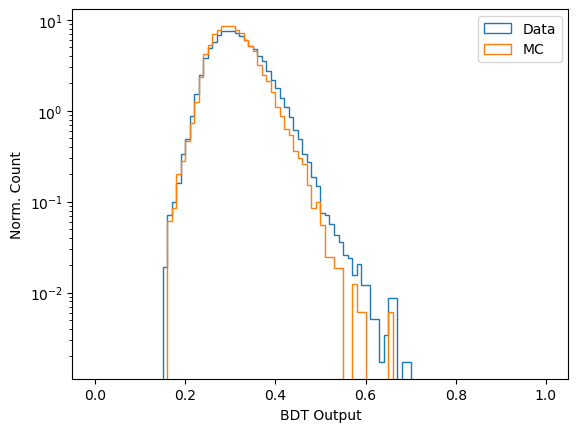

In [145]:
plt.hist(Yhat_final,bins=np.arange(0,1.01,0.01), histtype='step',density=True,label="Data")
plt.hist(df_test_combined['BDT'],bins=np.arange(0,1.01,0.01), histtype='step',density=True,label='MC')

plt.legend()
plt.yscale('log')
plt.xlabel('BDT Output')
plt.ylabel('Norm. Count')

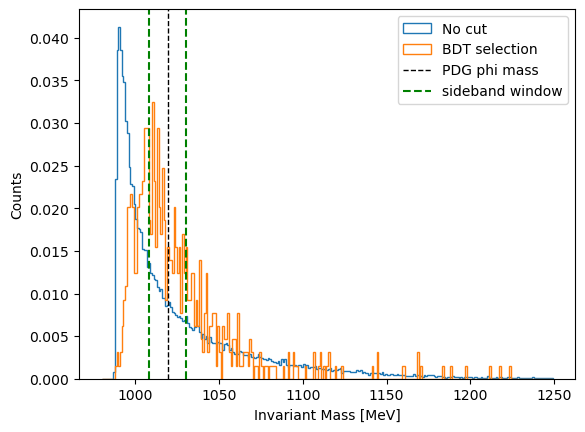

In [146]:
X_final_cut = X_final[X_final['pred']>BDT_selection].reset_index(drop=True)
x_vals = 1000*X_final_cut.InvM

X_final_cut = X_final[X_final['pred']>0].reset_index(drop=True)
x_vals2 = 1000*X_final_cut.InvM

plt.hist(x_vals2, bins=np.arange(980,1250,1), label="No cut", histtype='step',density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), label="BDT selection", histtype='step',density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.axvline(1030.3173980209851, color='g', linestyle='--', label='sideband window')
plt.axvline(1008.4829302730138, color='g', linestyle='--')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

